# SAE 204 : BDD - Groupe

Dictionnaire des tables SQL

| table\_name | column\_name | data\_type | is\_nullable |
| :--- | :--- | :--- | :--- |
| controller | controllerid | integer | NO |
| controller | modelid | integer | NO |
| controller | serialnumber | text | NO |
| controlmeasurement | sensorid | integer | NO |
| controlmeasurement | controllerid | integer | NO |
| controlmeasurement | sensortimestamp | timestamp  | NO |
| controlmeasurement | controltimestamp | timestamp  | NO |
| controlmeasurement | controlvalue | double precision | NO |
| model | unit | text | NO |
| model | modelid | integer | NO |
| model | brand | text | NO |
| model | model | text | NO |
| model | name | text | NO |
| sensor | validity | interval | NO |
| sensor | sensorid | integer | NO |
| sensor | serialnumber | text | NO |
| sensor | position | text | NO |
| sensor | modelid | integer | NO |
| sensormeasurement | timestamp | timestamp  | NO |
| sensormeasurement | sensorid | integer | NO |
| sensormeasurement | sensorvalue | double precision | NO |


Test de la connexion avec la base de données :

In [3]:
import psycopg

conn_params = {
    "host": "localhost",
    "dbname": "postgres",
    "user": "postgres",
    "password": "admin"
}

try:
    with psycopg.connect(**conn_params) as conn:
        print("Connection successful!")
        with conn.cursor() as cur:
            cur.execute("SELECT version();")
            print(cur.fetchone())
except psycopg.OperationalError as e:
    print(f"Connection failed: {e}")


Connection successful!
('PostgreSQL 16.13 (Ubuntu 16.13-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu, compiled by gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0, 64-bit',)


Script 1 - Erreurs entre mesures manuelles et automatiques :

In [4]:
import psycopg


def get_sensor_difference(conn_params):
    with psycopg.connect(**conn_params) as conn:
        with conn.cursor() as cur:
            cur.execute("""
                SELECT sensormeasurement.sensorid,
                       controlmeasurement.controlvalue - sensormeasurement.sensorvalue AS diff
                FROM controlmeasurement
                JOIN sensormeasurement
                    ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
                WHERE controlmeasurement.sensorid = 1
                ORDER BY controltimestamp
                LIMIT 50;
            """)

            for row in cur.fetchall():
                print(f"Sensor {row[0]} | Difference: {row[1]}")


if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    get_sensor_difference(conn_params)

Sensor 1 | Difference: -0.6928256070072949
Sensor 1 | Difference: -0.42472458437324756
Sensor 1 | Difference: -0.19717837492203405
Sensor 1 | Difference: -0.05734016940635911
Sensor 1 | Difference: 0.14345425626137076
Sensor 1 | Difference: -0.37765161701976624
Sensor 1 | Difference: -0.38994523019952476
Sensor 1 | Difference: 0.4336675151979643
Sensor 1 | Difference: 0.7761312024213797
Sensor 1 | Difference: -0.15902853772262193
Sensor 1 | Difference: -0.0590040671430998
Sensor 1 | Difference: 0.4418077118033801
Sensor 1 | Difference: 0.5576625971798089
Sensor 1 | Difference: -0.02724000068365151
Sensor 1 | Difference: -0.0610747926891686
Sensor 1 | Difference: -0.14927230955878212
Sensor 1 | Difference: 0.3453796731956025
Sensor 1 | Difference: 0.565314546846384
Sensor 1 | Difference: 0.19167603339857386
Sensor 1 | Difference: 0.8958946595656778
Sensor 1 | Difference: -0.1490143137199928
Sensor 1 | Difference: -0.08535771270845571
Sensor 1 | Difference: -0.18043561924514262
Sensor 1 

Script 2 - Moyenne et écart-type :

In [5]:
import psycopg


def get_sensor_statistics(conn_params):
    try:
        with psycopg.connect(**conn_params) as conn:
            with conn.cursor() as cur:
                cur.execute("""
                    SELECT sensorid,
                           AVG(sensorvalue) AS moyenne,
                           STDDEV(sensorvalue) AS ecart_type
                    FROM sensormeasurement
                    WHERE sensorid = 1
                    GROUP BY sensorid;
                """)

                row = cur.fetchone()

                if row:
                    print(f"Sensor {row[0]} | Average: {row[1]:.10f} | StdDev: {row[2]:.10f}")
                else:
                    print("No data found for this sensor.")

    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")


if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    get_sensor_statistics(conn_params)

Sensor 1 | Average: 0.0001409262 | StdDev: 1.2408729289


Script pour la carte de contrôle

Mean: -0.0037443199 | Standard deviation: 0.4127852187
Window: 8 days -> 33 points
Selected: 8 days (33 points)


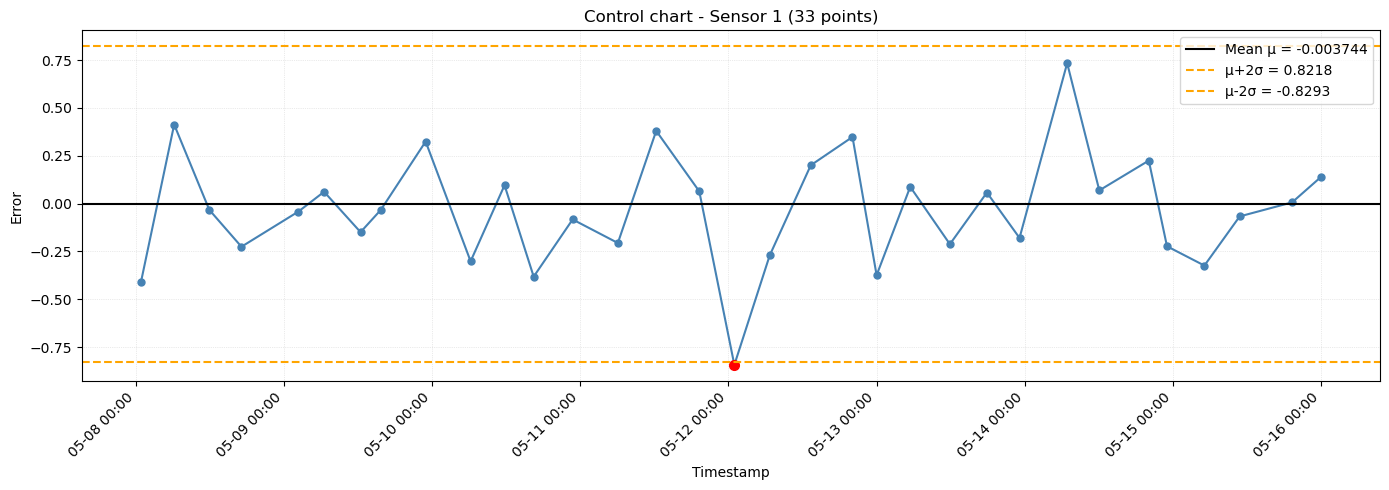

In [6]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

SENSOR_ID = 1
MAX_POINTS = 100
MIN_POINTS = 20

conn_params = dict(
    host="localhost",
    dbname="postgres",
    user="postgres",
    password="admin"
)


def get_sensor_statistics(conn_params):
    with psycopg.connect(**conn_params) as connection:
        cursor = connection.cursor()
        cursor.execute("""
            SELECT AVG(controlmeasurement.controlvalue - sensormeasurement.sensorvalue),
                   STDDEV(controlmeasurement.controlvalue - sensormeasurement.sensorvalue)
            FROM controlmeasurement
            JOIN sensormeasurement
              ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
            WHERE controlmeasurement.sensorid = %s
        """, (SENSOR_ID,))

        mean, standard_deviation = cursor.fetchone()

        if mean is None:
            return None, None

        print(f"Mean: {mean:.10f} | Standard deviation: {standard_deviation:.10f}")
        return float(mean), float(standard_deviation)


def get_sensor_difference(conn_params):
    with psycopg.connect(**conn_params) as connection:
        cursor = connection.cursor()

        for days in [8, 30, 90, 180, 365]:
            cursor.execute("""
                SELECT controlmeasurement.sensorid,
                       controlmeasurement.controlvalue - sensormeasurement.sensorvalue,
                       controlmeasurement.controltimestamp
                FROM controlmeasurement
                JOIN sensormeasurement
                  ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
                WHERE controlmeasurement.sensorid = %s
                  AND controlmeasurement.controltimestamp >= (
                      SELECT MAX(controltimestamp) - INTERVAL '1 day' * %s
                      FROM controlmeasurement
                      WHERE sensorid = %s
                  )
                ORDER BY controlmeasurement.controltimestamp DESC
                LIMIT %s
            """, (SENSOR_ID, days, SENSOR_ID, MAX_POINTS))

            rows = cursor.fetchall()
            print(f"Window: {days} days -> {len(rows)} points")

            if len(rows) >= MIN_POINTS:
                rows.reverse()
                print(f"Selected: {days} days ({len(rows)} points)")
                return rows

        rows.reverse()
        return rows


def plot_chart(data, mean, standard_deviation):
    timestamps = [row[2] for row in data]
    errors = [float(row[1]) for row in data]

    figure, axis = plt.subplots(figsize=(14, 5))
    axis.plot(timestamps, errors, marker='o', linestyle='-', color='steelblue', markersize=5)

    for timestamp, error in zip(timestamps, errors):
        if not (mean - 2 * standard_deviation <= error <= mean + 2 * standard_deviation):
            axis.plot(timestamp, error, 'ro', markersize=7)

    axis.axhline(mean, color='black', linewidth=1.5, label=f'Mean μ = {mean:.6f}')
    axis.axhline(mean + 2 * standard_deviation, color='orange', linestyle='--',
                 label=f'μ+2σ = {mean + 2 * standard_deviation:.4f}')
    axis.axhline(mean - 2 * standard_deviation, color='orange', linestyle='--',
                 label=f'μ-2σ = {mean - 2 * standard_deviation:.4f}')

    axis.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    axis.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45, ha='right')

    axis.set_title(f'Control chart - Sensor {SENSOR_ID} ({len(data)} points)')
    axis.set_xlabel('Timestamp')
    axis.set_ylabel('Error')
    axis.legend()
    axis.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    mean, standard_deviation = get_sensor_statistics(conn_params)
    data = get_sensor_difference(conn_params)

    if data and mean is not None:
        plot_chart(data, mean, standard_deviation)
    else:
        print("Unable to plot the chart: missing or insufficient data.")